# ARTI406 - Assignment 2
Data Preprocessing and PCA on YouTube Trending Videos Dataset

### Import Libraries and Load Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("USvideos.csv")

# Task 1: Identify Data Quality Issues

### 1.1 Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (40949, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


### 1.2 Finding Missing Values


In [4]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64

### 1.3 Finding Duplicate Records

In [5]:
df.duplicated().sum()

np.int64(48)

### 1.4 Checking Data Types

In [6]:
df.dtypes

video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

### 1.5 Summary Statistics

In [7]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


### 1.6 Data Quality Findings
The dataset contains 570 missing values in the description column and 48 duplicate records. Summary statistics indicate the presence of potential outliers in numerical features such as views, likes, and comment_count.

# Task 2: Apply One Missing Value Strategy and Explain Why

### 2.1 Missing Values Before Handling

In [8]:
print("Missing Values Before:")
print(df['description'].isnull().sum())

Missing Values Before:
570


### 2.2 Handling Missing Values

In [9]:
df['description'] = df['description'].fillna('No Description')

### 2.3 Missing Values After Handling

In [10]:
print("Missing Values After:")
print(df['description'].isnull().sum())

Missing Values After:
0


In [11]:
df.isnull().sum()

video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
dtype: int64

### 2.4 Explanation of the Selected Strategy
Missing values were found in the description column. Since description is a text feature, replacing missing values with the mean or median is not appropriate. Therefore, missing values were replaced with "No Description" to preserve all records and maintain consistency in the dataset.

In [12]:
df_clean = df.copy()

### 2.5 removing Duplicate Records

In [13]:
df = df.drop_duplicates()

In [14]:
print(df.duplicated().sum())

0


In [15]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (40901, 16)


# Task 3: Detect and Handle Outliers using IQR

### 3.1 Visualizing Outliers with Boxplots


In [16]:
features = ['views', 'likes', 'comment_count']

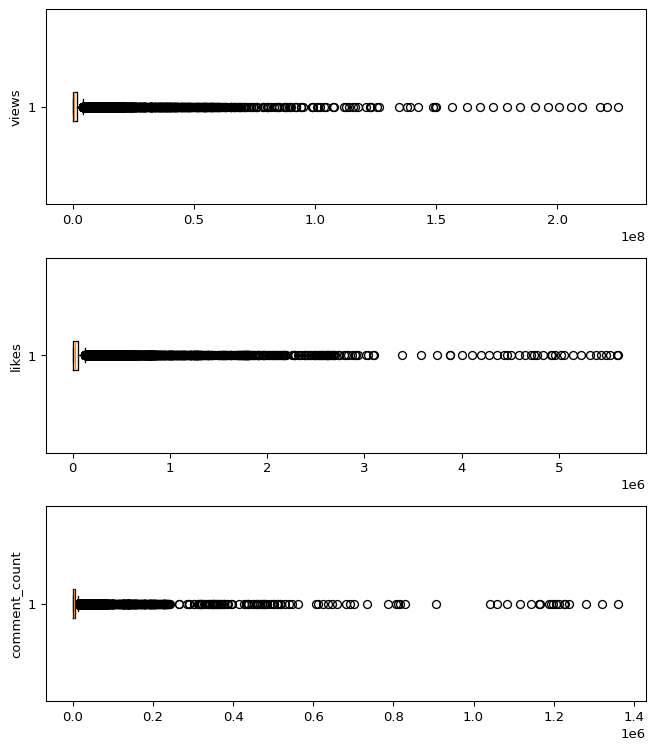

In [17]:
fig, axs = plt.subplots(len(features), 1, figsize=(7, 8), dpi=95)

for i, col in enumerate(features):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### 3.2 Calculating the Interquartile Range (IQR)

In [18]:
for feature in features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    print(feature)
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)

views
Q1 = 241972.0
Q3 = 1821926.0
IQR = 1579954.0
likes
Q1 = 5416.0
Q3 = 55338.0
IQR = 49922.0
comment_count
Q1 = 613.0
Q3 = 5752.0
IQR = 5139.0


### 3.3 Detecting Outliers

In [19]:
for feature in features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(f"\nFeature: {feature}")
    print("Number of Outliers:", len(outliers))


Feature: views
Number of Outliers: 4497

Feature: likes
Number of Outliers: 5137

Feature: comment_count
Number of Outliers: 5083


### 3.4 Removing Outliers

In [20]:
df_no_outliers = df.copy()

for feature in features:

    Q1 = df_no_outliers[feature].quantile(0.25)
    Q3 = df_no_outliers[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[feature] >= lower) &
        (df_no_outliers[feature] <= upper)
    ]

print("Outliers removed successfully.")

Outliers removed successfully.


### 3.5 Dataset Comparison Before and After Outlier Removal

In [21]:
print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_no_outliers.shape)

Original Shape: (40901, 16)
Shape After Removing Outliers: (30533, 16)


### 3.6 Boxplots After Outlier Removal

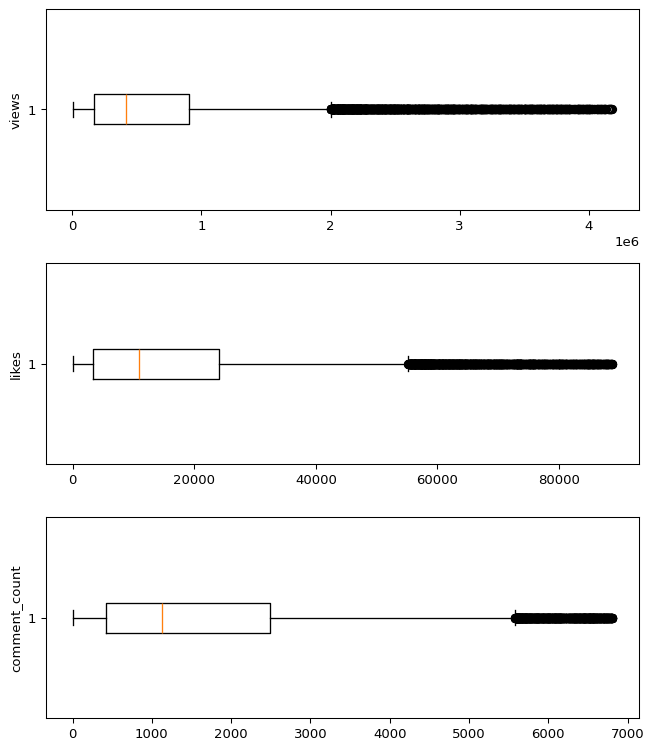

In [22]:
fig, axs = plt.subplots(len(features), 1, figsize=(7, 8), dpi=95)

for i, col in enumerate(features):
    axs[i].boxplot(df_no_outliers[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### 3.7 Interpretation
Outliers were detected in the views, likes, and comment_count features using the IQR method. Records outside the acceptable range were removed.

# Task 4: Normalize Numerical Features

### 4.1 Min-Max Normalization


In [23]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df_no_outliers.copy()

df_minmax[features] = minmax_scaler.fit_transform(
    df_no_outliers[features]
)

df_minmax[features].head()

,views,likes,comment_count
3,0.081903,0.114617,0.315264
5,0.028359,0.110008,0.210665
6,0.502688,0.180207,0.289408
7,0.195347,0.266631,0.504187
8,0.197337,0.039922,0.049949


### 4.2 Z-Score Normalization

In [24]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df_no_outliers.copy()

df_zscore[features] = zscore_scaler.fit_transform(
    df_no_outliers[features]
)
df_zscore[features].head()

,views,likes,comment_count
3,-0.440094,-0.376257,0.289725
5,-0.762337,-0.399032,-0.150460
6,2.092312,-0.052119,0.180915
7,0.242644,0.374978,1.084777
8,0.254624,-0.745388,-0.826811


# Task 5: Principal Component Analysis (PCA)


### Standardizing the Data

In [25]:
from sklearn.preprocessing import StandardScaler

X = df_no_outliers[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### 5.1 Applying PCA

In [26]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

### 5.2 Explained Variance Ratio

In [27]:
print(pca.explained_variance_ratio_)

[0.75286893 0.15471908 0.092412  ]


### 5.3 Cumulative Explained Variance

In [28]:
import numpy as np

print(np.cumsum(pca.explained_variance_ratio_))

[0.75286893 0.907588   1.        ]


### 5.4 PCA Visualization

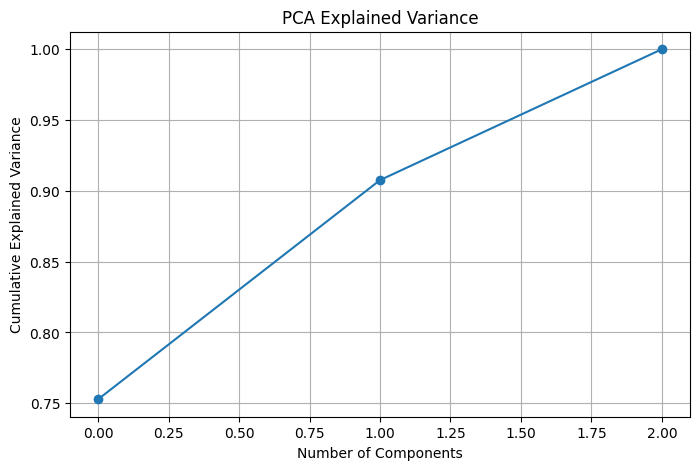

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.grid(True)
plt.show()

In [30]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print(X_pca_2.shape)

(30533, 2)


### 5.5 Interpretation of PCA Results
The first principal component explains 75.31% of the total variance in the dataset. The second principal component explains 15.46%, while the third component explains 9.23%. Together, the first two principal components retain approximately 90.77% of the total information, indicating that dimensionality reduction can be achieved with minimal information loss.